In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))
from train import train_model
from mlp import MLP
from data import load_mnist_subset
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt

In [26]:
model = MLP(48)
is_underparam = True
X_train, y_train, X_test, y_test = load_mnist_subset()
y_train_onehot = F.one_hot(y_train, num_classes=10).float()
y_test_onehot = F.one_hot(y_test, num_classes=10).float()

trained_model, losses = train_model(model, X_train, y_train_onehot, is_underparam)

In [27]:
train_preds = trained_model(X_train).argmax(dim=1)
train_error = (train_preds != y_train).float().mean().item()
train_acc = np.round((1 - train_error)*100, 1)

print(f"Train data acc: {train_acc}")

test_preds = trained_model(X_test).argmax(dim=1)
test_error = (test_preds != y_test).float().mean().item()
test_acc = np.round((1 - test_error)*100, 1)

print(f"Test data acc: {test_acc}")

Train data acc: 99.2
Test data acc: 93.0


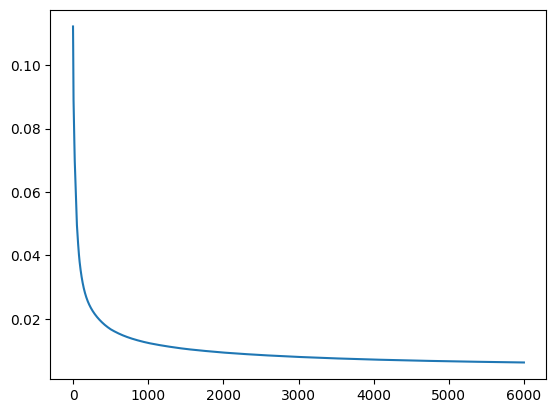

In [28]:
plt.plot(losses)

In [34]:
np.mean((trained_model(X_test) - y_test_onehot).detach().numpy()**2)

np.float32(0.01805056)